In [2]:
# Install the missing library
%pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
import pandas as pd
# Load the data from the local CSV file using a relative path
# The notebook is in 'notebooks/' and the data is in 'data/raw/', so '..' goes up one directory
df = pd.read_csv('../data/raw/creditcard.csv')

# Print the shape of the DataFrame to verify the load
# The expected output is (284807, 31)
print(df.shape)


(284807, 31)


In [5]:
# Display the first 5 rows of the DataFrame 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Check data types, non-null counts, and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
# Explicitly count missing values per column
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# Generate descriptive statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
# 1. Get the raw counts of each class
occ = df['Class'].value_counts()
print("Transaction Counts:")
print(occ)

# 2. Calculate the percentage of fraud (Class 1)
# Divide the fraud count by the total rows and multiply by 100
fraud_percentage = (occ[1] / len(df)) * 100 

print(f"\nPercentage of Fraudulent Transactions: {fraud_percentage:.4f}%")

Transaction Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of Fraudulent Transactions: 0.1727%


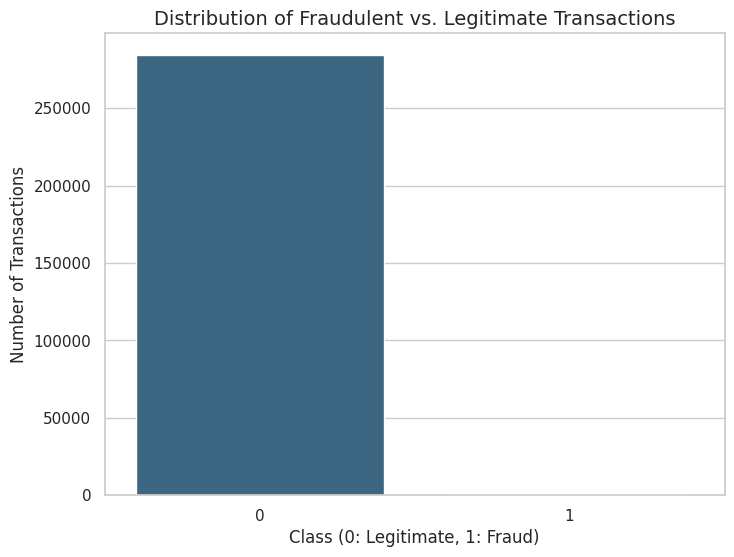

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style and figure size 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))

# 2. Create the bar plot 
# I use the 'occ' variable (counts) that I created in the previous cell
ax = sns.barplot(x=occ.index, y=occ.values, hue=occ.index, palette="viridis", legend=False)

# 3. Add labels and title
plt.title('Distribution of Fraudulent vs. Legitimate Transactions', fontsize=14)
plt.xlabel('Class (0: Legitimate, 1: Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# 4. Show the plot
plt.show()

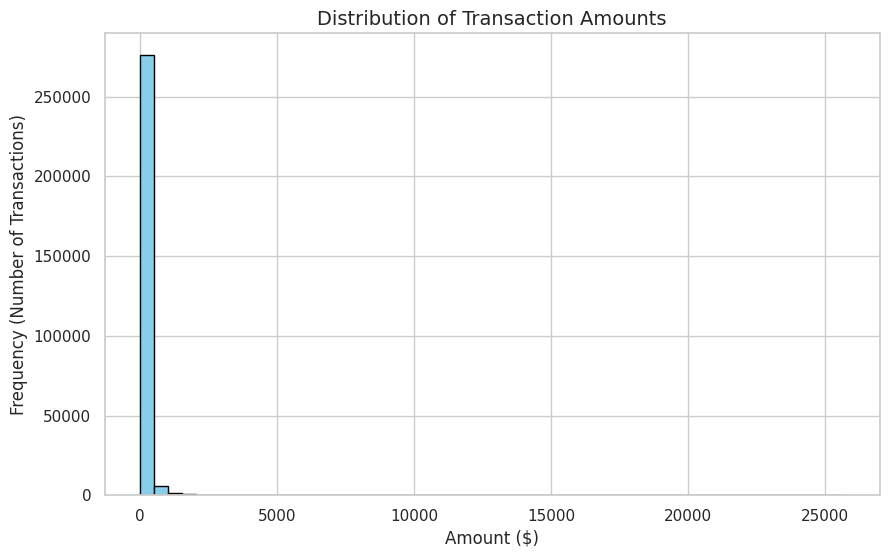

In [12]:
# Create a histogram of the Amount column
plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=50, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Distribution of Transaction Amounts', fontsize=14)
plt.xlabel('Amount ($)', fontsize=12)
plt.ylabel('Frequency (Number of Transactions)', fontsize=12)

plt.show()

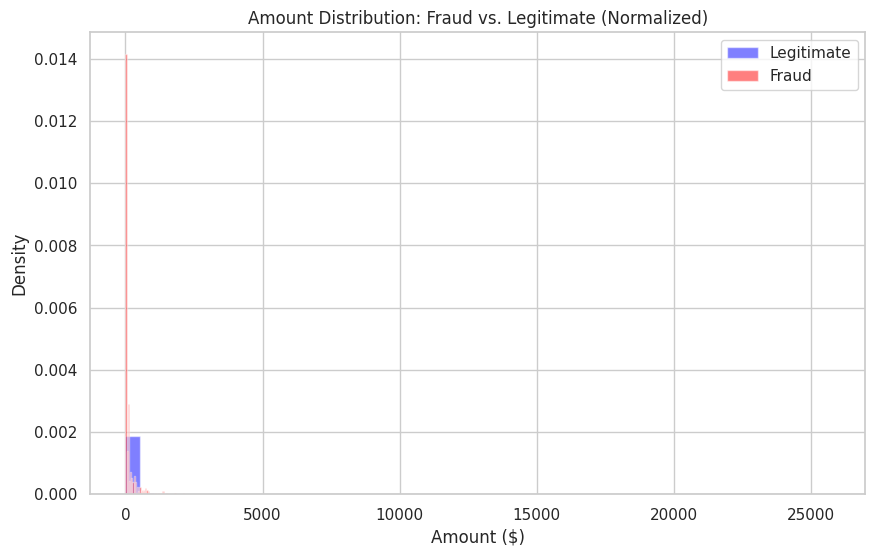

In [13]:
# 1. Filter the data into two groups
legit = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

# 2. Plot overlapping histograms
plt.figure(figsize=(10, 6)) 
plt.hist(legit["Amount"], bins=50, alpha=0.5, label="Legitimate", color="blue", density=True)
plt.hist(fraud["Amount"], bins=50, alpha=0.5, label="Fraud", color="red", density=True)

# 3. Add details
plt.title("Amount Distribution: Fraud vs. Legitimate (Normalized)")
plt.xlabel("Amount ($)")
plt.ylabel("Density")
plt.legend()
plt.show()


/tmp/ipykernel_37986/2588938131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= 'Class', y='Amount', data=df, palette="Set2")


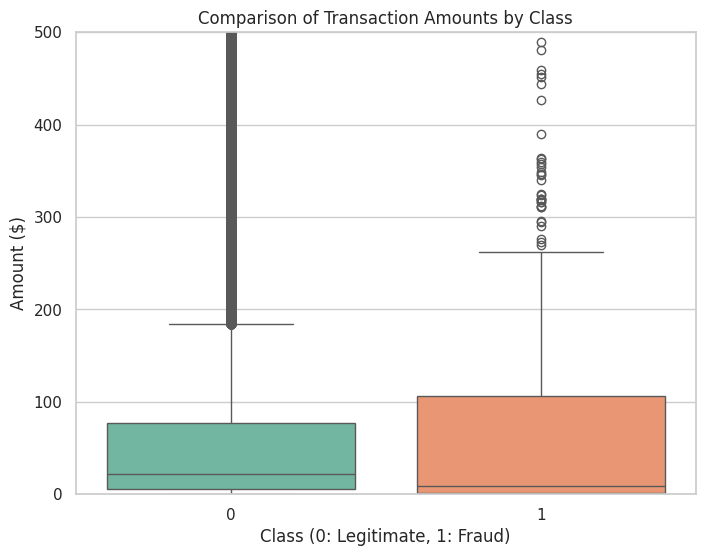

In [14]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x= 'Class', y='Amount', data=df, palette="Set2")

# Limit y-axis to see the "boxes" better, as extreme outliers will squash them
plt.ylim(0, 500)

plt.title('Comparison of Transaction Amounts by Class')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Amount ($)')
plt.show()

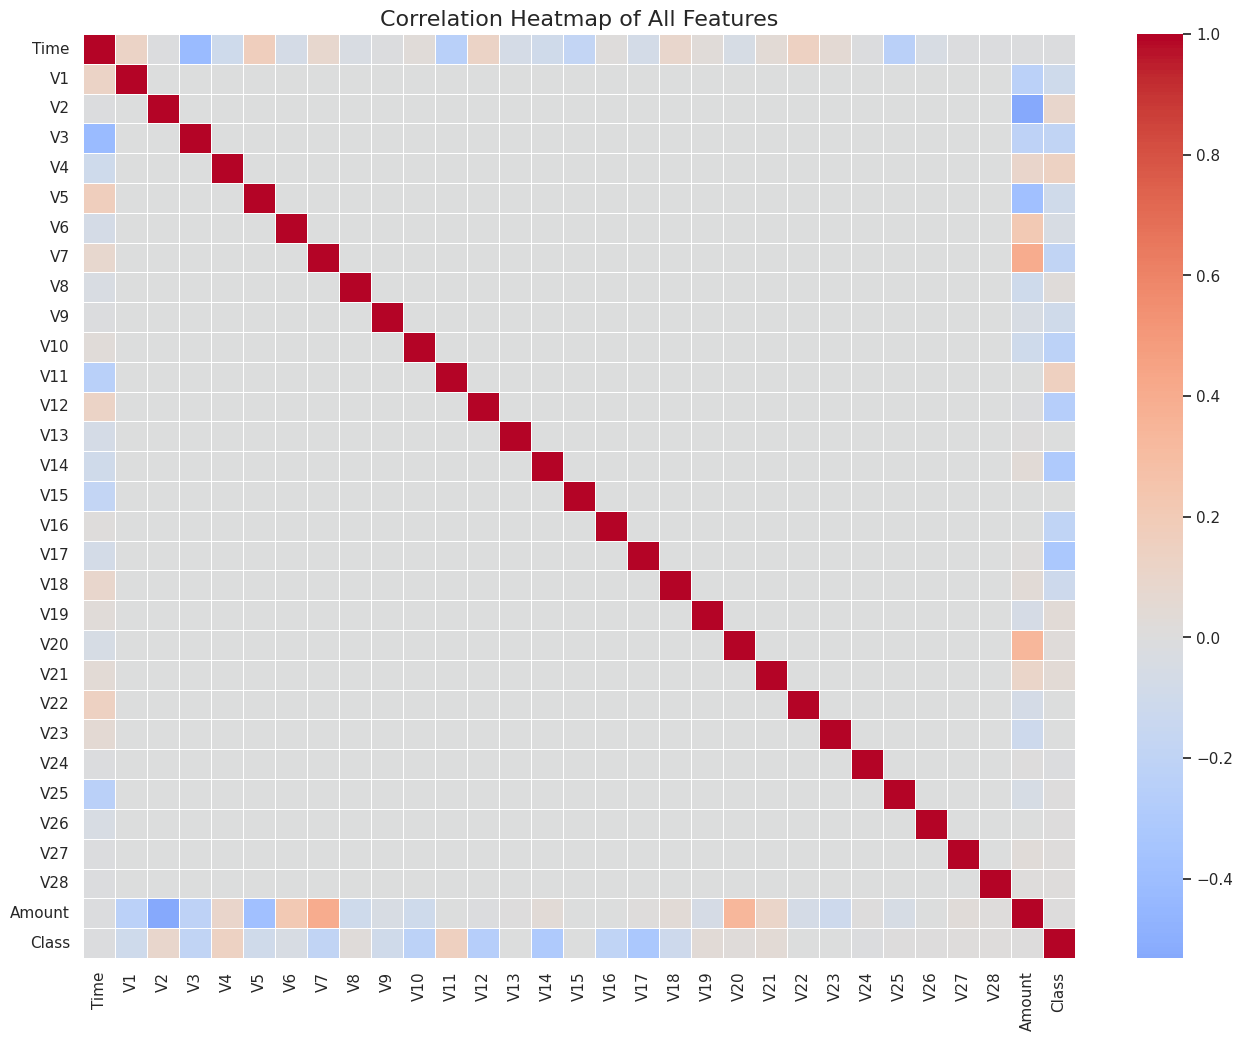

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix
corr_matrix = df.corr()

# 2. Set the figure size to handle 31 columns
plt.figure(figsize=(16, 12))

# 3. Create the heatmap
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            annot=False,   # Set to True if youy want to see the actual numbers
            linewidths=0.5)

# 4. Add titles and labels
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.show()

In [16]:
# 1. Get correlations specifically for the 'Class' column
correlations = df.corr()['Class']

# 2. Sort them by absolute value to find the strongest relationships (positive or negative)
top_correlations = correlations.abs().sort_values(ascending=False)

print("Top Features Correlated with Fraud:")
print(top_correlations.head(10))

# 3. Look at the raw values (not absolute) to see direction (Positive vs Negative)
print("\nRaw Correlation Values for Top Features:")
print(correlations[top_correlations.index[1:6]]) # Skipping 'Class' itself at index 0

Top Features Correlated with Fraud:
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64

Raw Correlation Values for Top Features:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


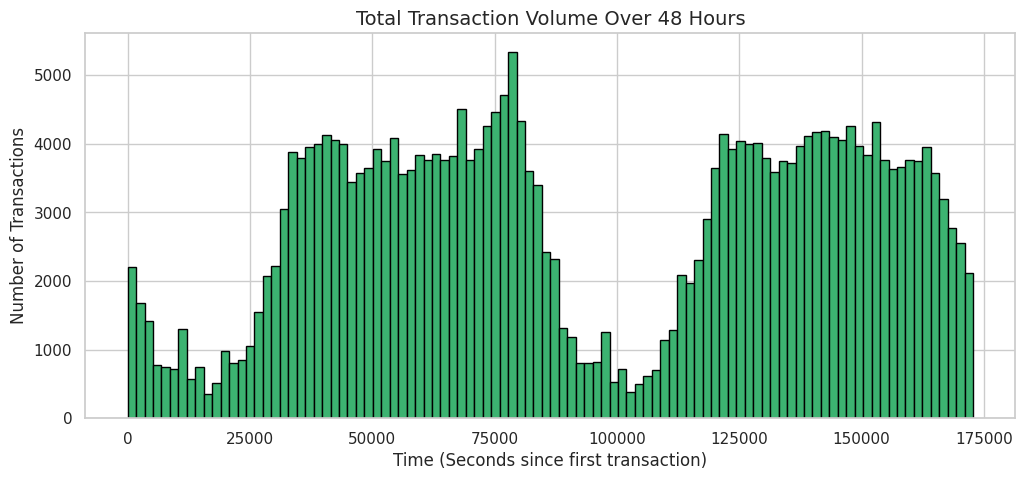

In [17]:
import matplotlib.pyplot as plt

# Plot the overall distribution of Time
plt.figure(figsize=(12, 5))
plt.hist(df['Time'], bins=100, color='mediumseagreen', edgecolor='black')

plt.title('Total Transaction Volume Over 48 Hours', fontsize=14)
plt.xlabel('Time (Seconds since first transaction)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.show()


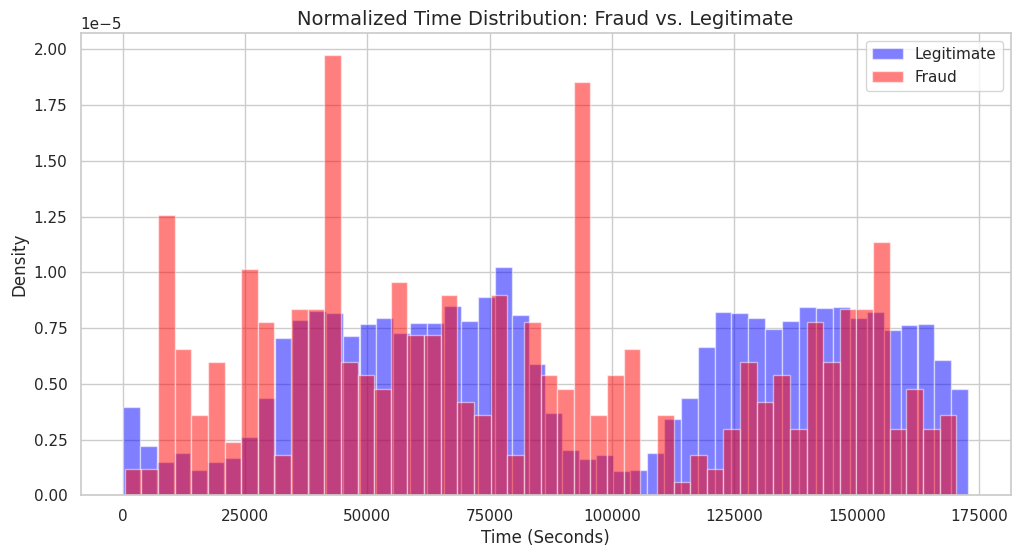

In [18]:
# 1. Filter the data
legit_time = df[df['Class'] == 0]['Time']
fraud_time = df[df['Class'] == 1]['Time']

# 2. Plot overlapping histograms
plt.figure(figsize=(12, 6))
plt.hist(legit_time, bins=50, alpha=0.5, label='Legitimate', color='blue', density=True)
plt.hist(fraud_time, bins=50, alpha=0.5, label='Fraud', color='red', density=True)

# 3. Formatting
plt.title('Normalized Time Distribution: Fraud vs. Legitimate', fontsize=14)
plt.xlabel('Time (Seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()


In [19]:
# Group by Class and calculate the mean for all features
class_summary = df.groupby('Class').mean()

# Display the summary table
class_summary


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [20]:
from sklearn.preprocessing import RobustScaler

# 1. Initialize the RobustScaler
rob_scaler = RobustScaler()

# 2. Scale 'Amount' and 'Time' and create new columns
# We use .values.reshape(-1,1) because the scaler expects a 2D array
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# 3. Drop the original 'Time' and 'Amount' columns so we don't have redundant data
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# 4. Move our new scaled columns to the front of the DataFrame for easy viewing
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# View the first 5 rows to confirm the change
df.head()


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [21]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) from the target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Split the data
# stratify=y is critical for imbalanced data to ensure both sets have the same % of fraud
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Print the shapes to verify
print(f"Training Set: {X_train.shape[0]} rows")
print(f"Testing Set: {X_test.shape[0]} rows")

# 4. Verify that the fraud ratio is the same in both
print(f"\nFraud in Training: {y_train.value_counts(normalize=True)[1]:.4%}")
print(f"Fraud in Testing: {y_test.value_counts(normalize=True)[1]:.4%}")


Training Set: 227845 rows
Testing Set: 56962 rows

Fraud in Training: 0.1729%
Fraud in Testing: 0.1720%


In [23]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

# --- Strategy A: Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_undersample, y_undersample = rus.fit_resample(X_train, y_train)

print(f"Undersampled dataset shape: {Counter(y_undersample)}")

# --- Strategy B: SMOTE (Oversampling) ---
sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X_train, y_train)

print(f"SMOTE dataset shape: {Counter(y_smote)}")


Undersampled dataset shape: Counter({0: 394, 1: 394})
SMOTE dataset shape: Counter({0: 227451, 1: 227451})


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize and train the model on Undersampled data
lr = LogisticRegression(max_iter=1000)
lr.fit(X_undersample, y_undersample)

# 2. Make predictions on the hidden Test Set (the real-world data)
y_pred = lr.predict(X_test)

# 3. Evaluate the results
print("--- Logistic Regression (Undersampled) Results ---")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


--- Logistic Regression (Undersampled) Results ---
[[54612  2252]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



In [25]:
# 1. Initialize and train the model on SMOTE data
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_smote, y_smote)

# 2. Make predictions on the same hidden Test Set
y_pred_smote = lr_smote.predict(X_test)

# 3. Evaluate the results
print("--- Logistic Regression (SMOTE) Results ---")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))


--- Logistic Regression (SMOTE) Results ---
[[55430  1434]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



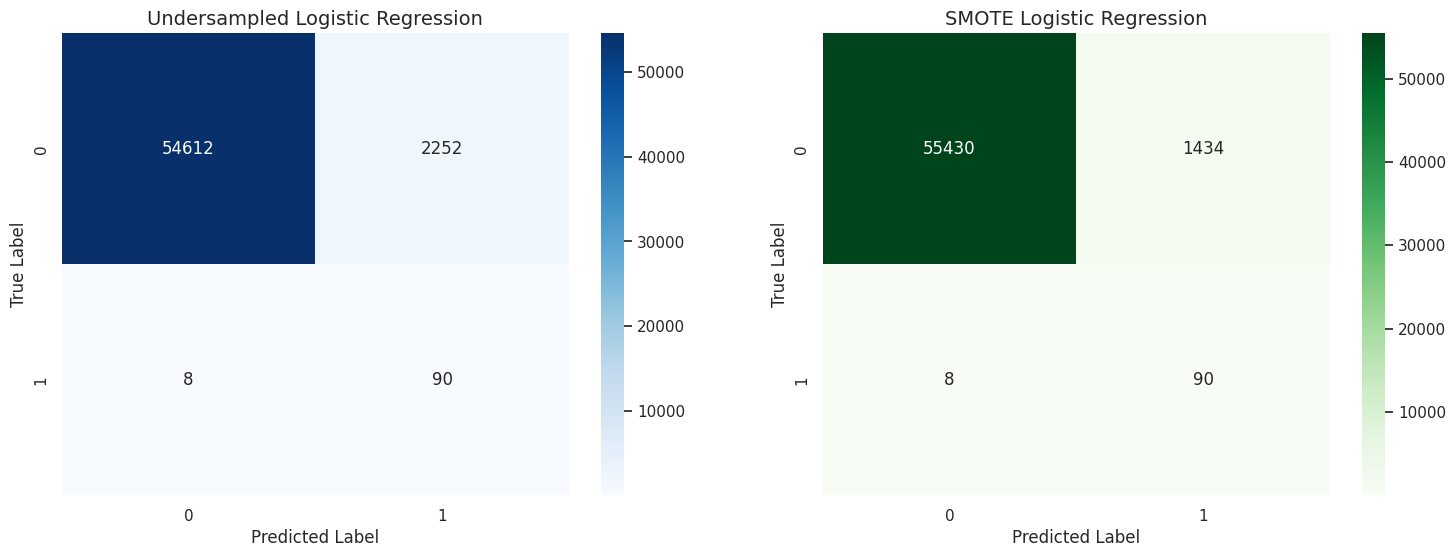

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a figure with two side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 2. Plot for Undersampled Model
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Undersampled Logistic Regression', fontsize=14)
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# 3. Plot for SMOTE Model
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('SMOTE Logistic Regression', fontsize=14)
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.show()


/tmp/ipykernel_37986/2392111426.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')


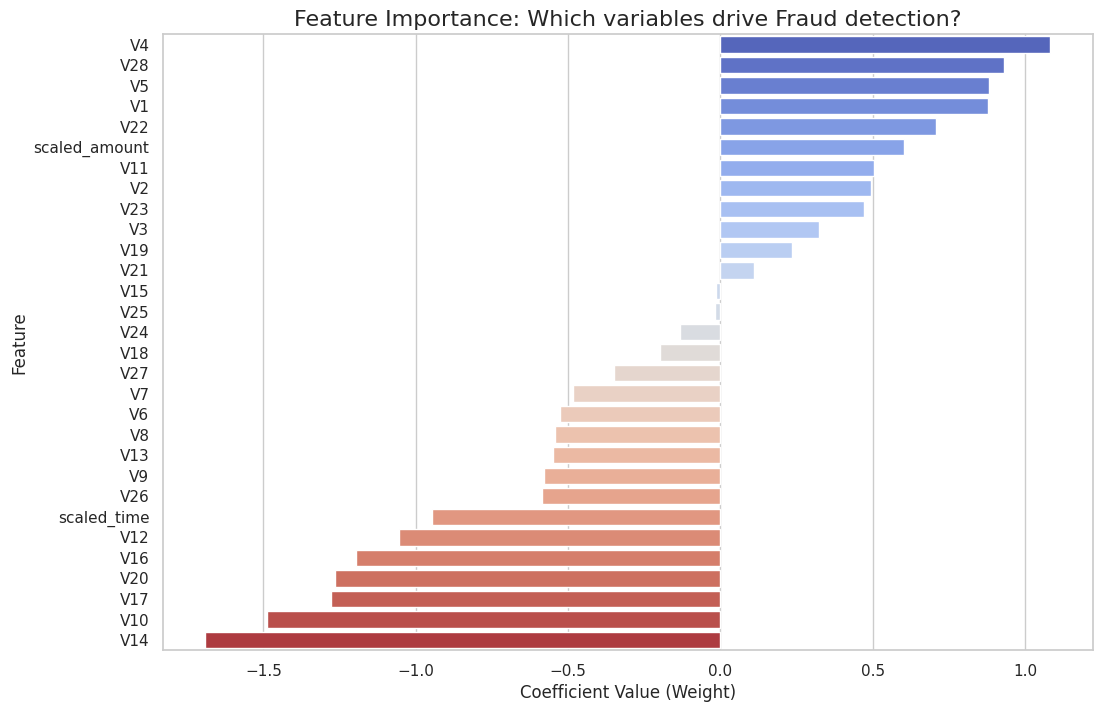

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract coefficients from the SMOTE model
# .coef_[0] gives us the weight for each feature
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': lr_smote.coef_[0]})

# 2. Sort by the magnitude (absolute value) to see the strongest predictors
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('Feature Importance: Which variables drive Fraud detection?', fontsize=16)
plt.xlabel('Coefficient Value (Weight)', fontsize=12)
plt.show()


In [28]:
import joblib

# 1. Save the SMOTE-trained Logistic Regression model
joblib.dump(lr_smote, 'fraud_detection_model.pkl')

# 2. Save the RobustScaler (crucial for future data to match the model)
joblib.dump(rob_scaler, 'amount_time_scaler.pkl')

print("Success: Model and Scaler saved as .pkl files!")


Success: Model and Scaler saved as .pkl files!
